# **1. Perkenalan Dataset**



1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari Kaggle dengan judul Credit Card Fraud Detection (https://www.kaggle.com/datasets/bhadramohit/credit-card-fraud-detection/data)

Dataset yang digunakan adalah Credit Card Fraud Detection Dataset yang berisi 100.000 data simulasi transaksi kartu kredit. Target variabel proyek ini adalah IsFraud (1 untuk transaksi fraud, 0 untuk transaksi sah). Karena ini kasus fraud, metrik utama yang dikejar adalah Recall dan F1-Score karena adanya class imbalance.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df = pd.read_csv("credit_card_fraud_dataset.csv")

print("Ukuran Dataset:", df.shape)
df.head()

Ukuran Dataset: (100000, 7)


,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TransactionID    100000 non-null  int64  
 1   TransactionDate  100000 non-null  object 
 2   Amount           100000 non-null  float64
 3   MerchantID       100000 non-null  int64  
 4   TransactionType  100000 non-null  object 
 5   Location         100000 non-null  object 
 6   IsFraud          100000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 5.3+ MB
None

Distribusi Kelas Target:
IsFraud
0    99.0
1     1.0
Name: proportion, dtype: float64


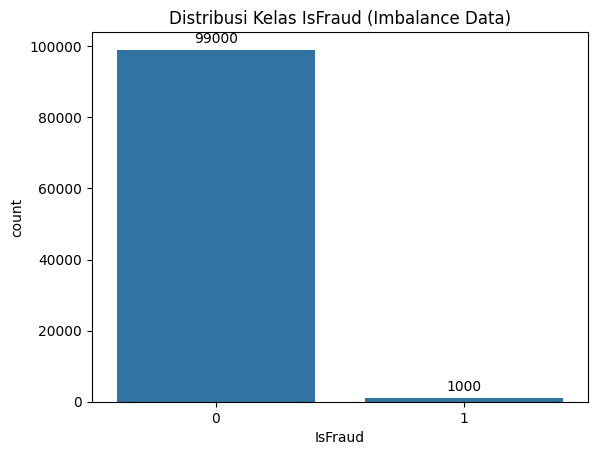

In [4]:
# Info tipe data dan missing value
print(df.info())

# Cek persentase imbalance target
print("\nDistribusi Kelas Target:")
print(df['IsFraud'].value_counts(normalize=True) * 100)

# Plot distribusi target
ax = sns.countplot(data=df, x='IsFraud')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title("Distribusi Kelas IsFraud (Imbalance Data)")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [6]:
# 1. Menangani/menghapus kolom identifier tidak punya nilai prediktif
df_clean = df.drop(columns=['TransactionID', 'MerchantID'], errors='ignore')

# 2. Rekayasa fitur waktu (feature engineering dari TransactionDate)
# Mengubah object string menjadi datetime agar bisa di ekstrak komponen pentingnya,karena pola transaksi fraud sering terjadi di jam-jam atau hari-hari tertentu.
df_clean['TransactionDate'] = pd.to_datetime(df_clean['TransactionDate'])
df_clean['Hour'] = df_clean['TransactionDate'].dt.hour
df_clean['DayOfWeek'] = df_clean['TransactionDate'].dt.dayofweek
# Hapus kolom aslinya karena sudah diwakili oleh fitur Hour dan DayOfWeek
df_clean = df_clean.drop(columns=['TransactionDate'], errors='ignore')

# 3. Encoding data kategorikal (TransactionType & Location)
df_clean = pd.get_dummies(df_clean, columns=['TransactionType', 'Location'], drop_first=True)

# 4. Mengecek hasil akhir preprocessing
print("=== UKURAN DATA SETELAH PREPROCESSING ===")
print(df_clean.shape)
print("\n=== 5 DATA TERATAS YANG SIAP UNTUK RETRAINING ===")
print(df_clean.head())

# 5. Menyimpan hasil preprocessing ke file CSV baru'
df_clean.to_csv("credit_card_fraud_clean.csv", index=False)
print("\nFile 'credit_card_fraud_clean.csv' berhasil disimpan")

=== UKURAN DATA SETELAH PREPROCESSING ===
(100000, 14)

=== 5 DATA TERATAS YANG SIAP UNTUK RETRAINING ===
    Amount  IsFraud  Hour  DayOfWeek  TransactionType_refund  Location_Dallas  \
0  4189.27        0    14          2                    True            False   
1  2659.71        0    13          1                    True             True   
2   784.00        0    10          0                   False            False   
3  3514.40        0    23          5                   False            False   
4   369.07        0    18          4                   False            False   

   Location_Houston  Location_Los Angeles  Location_New York  \
0             False                 False              False   
1             False                 False              False   
2             False                 False               True   
3             False                 False              False   
4             False                 False              False   

   Location_Philadelph